<a href="https://colab.research.google.com/github/Satyapriyo/Final-Year-Project/blob/test-code/final_emotion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  # Using PyTorch's implementation of AdamW
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

In [ ]:
# Set random seed for reproducibility
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# 1. Load your dataset
# You can replace this with your dataset or use one of the recommended datasets
df = pd.read_csv("figurative_language_four_emotions.csv")
print(f"Dataset loaded with shape: {df.shape}")
print(df['emotion'].value_counts())

Dataset loaded with shape: (79099, 2)
emotion
Anger    30997
Happy    19231
Love     14880
Sad      13991
Name: count, dtype: int64


In [ ]:
# Convert emotion labels to numeric values
label_encoder = LabelEncoder()
df['encoded_emotion'] = label_encoder.fit_transform(df['emotion'])
num_labels = len(label_encoder.classes_)
print(f"Emotion classes: {label_encoder.classes_}")

Emotion classes: ['Anger' 'Happy' 'Love' 'Sad']


In [ ]:
# Print label mapping for reference
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

Anger: 0
Happy: 1
Love: 2
Sad: 3


In [ ]:

# 2. Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    df['text'].values,
    df['encoded_emotion'].values,
    test_size=0.2,
    random_state=seed_val,
    stratify=df['encoded_emotion'].values  # Ensure balanced classes in both sets
)

In [ ]:
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")


Training set size: 63279
Validation set size: 15820


In [ ]:

# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 128  # You can adjust this based on your text lengths

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# 4. Tokenize and encode the datasets
def encode_texts(texts, tokenizer, max_length):
    """Tokenize and encode a list of texts."""
    return tokenizer(
        texts.tolist() if isinstance(texts, np.ndarray) else texts,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )


In [ ]:
# Encode training and validation sets
train_encodings = encode_texts(X_train, tokenizer, max_length)
val_encodings = encode_texts(X_val, tokenizer, max_length)

In [ ]:
# Create PyTorch datasets
train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    val_encodings['input_ids'],
    val_encodings['attention_mask'],
    torch.tensor(y_val, dtype=torch.long)
)

In [ ]:
# 5. Create data loaders
batch_size = 16

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

val_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)


In [ ]:
# 6. Load pre-trained BERT model and configure for fine-tuning
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    output_attentions=False,
    output_hidden_states=False,
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 7. Set up optimizer and learning rate scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Total steps for learning rate scheduler
total_steps = len(train_dataloader) * 4  # 4 epochs
warmup_steps = int(total_steps * 0.1)  # 10% of total steps for warm-up

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [ ]:
# 8. Define training function
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train the model for one epoch."""
    model.train()
    total_loss = 0

    # Progress bar for training
    progress_bar = tqdm(dataloader, desc="Training", leave=True)

    for batch in progress_bar:
        # Unpack batch and move to device
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        # Clear gradients
        model.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weights
        optimizer.step()

        # Update learning rate
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)




In [ ]:
# 9. Define evaluation function
def evaluate(model, dataloader, device):
    """Evaluate the model on validation data."""
    model.eval()
    val_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=True):
            # Unpack batch and move to device
            input_ids, attention_mask, labels = [b.to(device) for b in batch]

            # Forward pass
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            val_loss += loss.item()

            # Get predictions
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            batch_labels = labels.cpu().numpy()

            predictions.extend(batch_preds)
            true_labels.extend(batch_labels)

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    report = classification_report(true_labels, predictions, target_names=label_encoder.classes_, output_dict=True)

    return val_loss / len(dataloader), accuracy, report, predictions, true_labels

In [ ]:
# 10. Move model to device
model.to(device)

# 11. Training loop
epochs = 4
best_val_accuracy = 0
training_stats = []

for epoch in range(epochs):
    print(f"\n{'=' * 30}")
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"{'=' * 30}")

    # Train
    train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

    # Evaluate
    val_loss, val_accuracy, val_report, predictions, true_labels = evaluate(model, val_dataloader, device)

    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    # Print classification report
    for emotion, metrics in val_report.items():
        if emotion in label_encoder.classes_:
            print(f"{emotion} - Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1-score']:.4f}")

    # Save stats for plotting
    training_stats.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
    })

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        print("Saving best model...")

        # Create directory if it doesn't exist
        os.makedirs('emotion_bert_model', exist_ok=True)

        # Save model and tokenizer
        model.save_pretrained('./emotion_bert_model')
        tokenizer.save_pretrained('./emotion_bert_model')

        # Save label encoder mapping
        np.save('./emotion_bert_model/label_encoder_classes.npy', label_encoder.classes_)


Epoch 1/4


Training:   2%|▏         | 84/3955 [29:46<22:42:15, 21.11s/it, loss=1.3830]

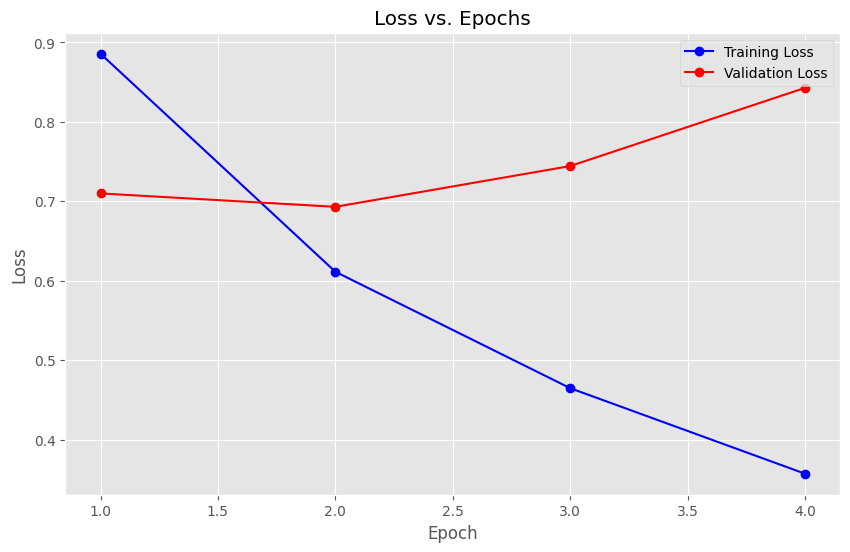

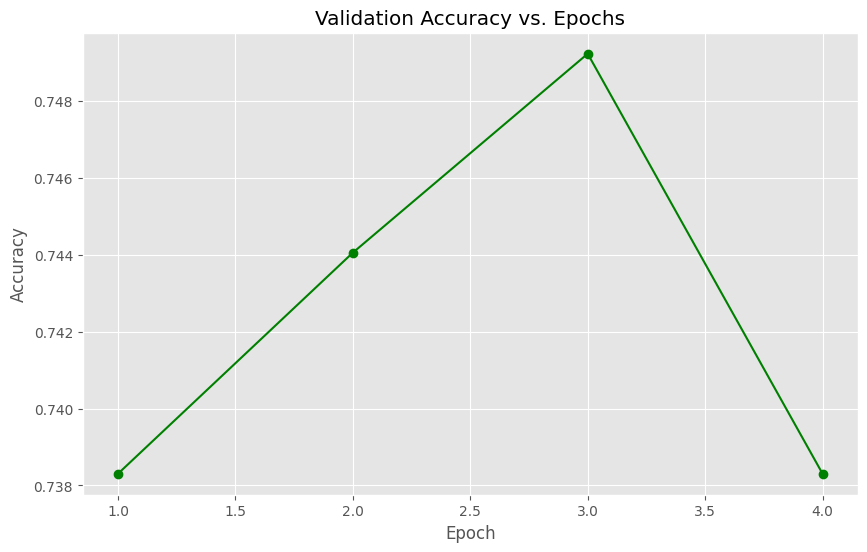

In [ ]:
# 12. Plot training results
stats_df = pd.DataFrame(training_stats)

# Set style for plots
plt.style.use('ggplot')

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(stats_df['epoch'], stats_df['train_loss'], 'b-o', label='Training Loss')
plt.plot(stats_df['epoch'], stats_df['val_loss'], 'r-o', label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('./emotion_bert_model/loss_plot.png')
plt.show()

# Plot accuracy
plt.figure(figsize=(10, 6))
plt.plot(stats_df['epoch'], stats_df['val_accuracy'], 'g-o')
plt.title('Validation Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig('./emotion_bert_model/accuracy_plot.png')
plt.show()

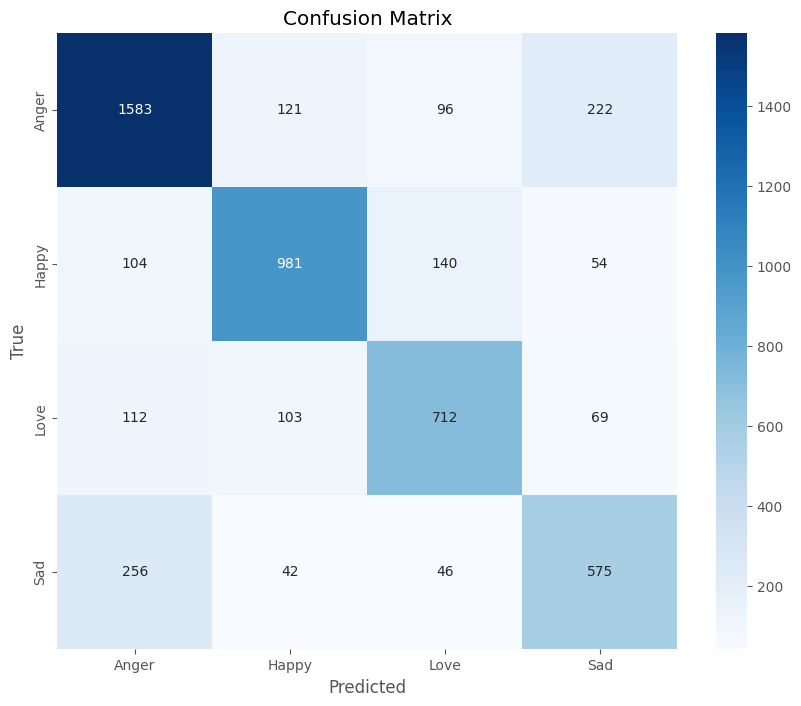

In [ ]:
# 13. Create confusion matrix for the best model
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('./emotion_bert_model/confusion_matrix.png')
plt.show()

In [ ]:
# 14. Function to predict emotion for new texts
def predict_emotion(texts, model, tokenizer, label_encoder, max_length=128):
    """Predict emotions for a list of texts."""
    # Move model to evaluation mode
    model.eval()

    # Tokenize and encode texts
    encodings = encode_texts(texts, tokenizer, max_length)

    # Create tensor dataset
    dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'])

    # Create dataloader
    dataloader = DataLoader(dataset, batch_size=32)

    # Make predictions
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask = [b.to(device) for b in batch]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(batch_preds)

    # Convert numeric predictions to emotion labels
    emotion_predictions = label_encoder.inverse_transform(predictions)

    return emotion_predictions


In [ ]:
# 15. Test with some example texts
example_texts = [
    "Thank you for failing me.",
    "The sadness was overwhelming after hearing the news.",
    "His anger boiled over when he discovered the betrayal.",
    "The joy of reunion filled the entire room with light."
]

# Load the best model
best_model = BertForSequenceClassification.from_pretrained('./emotion_bert_model')
best_model.to(device)

# Predict emotions for example texts
predicted_emotions = predict_emotion(example_texts, best_model, tokenizer, label_encoder)

# Print predictions
print("\nExample predictions:")
for text, emotion in zip(example_texts, predicted_emotions):
    print(f"Text: {text}")
    print(f"Predicted emotion: {emotion}\n")

print("Model training and evaluation complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Model saved to: ./emotion_bert_model")


Example predictions:
Text: Thank you for failing me.
Predicted emotion: Sad

Text: The sadness was overwhelming after hearing the news.
Predicted emotion: Sad

Text: His anger boiled over when he discovered the betrayal.
Predicted emotion: Anger

Text: The joy of reunion filled the entire room with light.
Predicted emotion: Happy

Model training and evaluation complete.
Best validation accuracy: 0.7492
Model saved to: ./emotion_bert_model
